In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

groq_key = os.environ["GROQ_API_KEY"]
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=groq_key)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016ACF7F28D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016ACF955250>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
def bot(state:State):
    return {"messages": [llm.invoke(state['messages'])]}

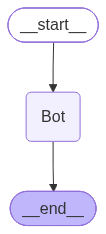

In [10]:
from IPython.display import Image, display

graph = StateGraph(State)

graph.add_node("Bot", bot)

graph.add_edge(START, "Bot")
graph.add_edge("Bot", END)

graph_build = graph.compile()

display(Image(graph_build.get_graph().draw_mermaid_png()))

In [14]:
graph_build.invoke({"messages": "Hi, I am Shivam"})

{'messages': [HumanMessage(content='Hi, I am Shivam', additional_kwargs={}, response_metadata={}, id='3f73f144-2680-4dcb-8f44-e31d880d2561'),
  AIMessage(content='Hello Shivam! 👋 How can I assist you today?', additional_kwargs={'reasoning_content': "We need to respond politely. There's no specific request. We can ask how to help."}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 77, 'total_tokens': 118, 'completion_time': 0.062253625, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.003871046, 'prompt_tokens_details': None, 'queue_time': 0.316188734, 'total_time': 0.066124671}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_996f667773', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06676-94eb-7af1-b217-3a06db897151-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 41, 'total_tokens': 118, 'output_token_detai